In [1]:
import seaborn as sns

tips = sns.load_dataset('tips')
df = tips.copy()
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [3]:
#Transformações
#sex, smoker, time
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

df = pd.get_dummies(df, columns=['sex', 'smoker', 'time'], dtype=int, drop_first=True)
ordinal = OrdinalEncoder(categories=[['Thur','Fri','Sat','Sun']])
df['day_encoder'] = ordinal.fit_transform(df[['day']])
df.drop('day', axis=1, inplace=True)
df.head()


,total_bill,tip,size,sex_Female,smoker_No,time_Dinner,day_encoder
0,16.99,1.01,2,1,1,1,3.0
1,10.34,1.66,3,0,1,1,3.0
2,21.01,3.50,3,0,1,1,3.0
3,23.68,3.31,2,0,1,1,3.0
4,24.59,3.61,4,1,1,1,3.0


In [5]:
#Separar atributos preditivos (X) e o alvo contínuo (y)
X = df.drop(['tip'],axis=1).copy()
y = df['tip']

In [6]:
pd.concat([X.head(3), y.head(3)])

,total_bill,size,sex_Female,smoker_No,time_Dinner,day_encoder,tip
0,16.99,2.0,1.0,1.0,1.0,3.0,NaN
1,10.34,3.0,0.0,1.0,1.0,3.0,NaN
2,21.01,3.0,0.0,1.0,1.0,3.0,NaN
0,NaN,NaN,NaN,NaN,NaN,NaN,1.01
1,NaN,NaN,NaN,NaN,NaN,NaN,1.66
2,NaN,NaN,NaN,NaN,NaN,NaN,3.50


In [7]:
#Classificando a gorjeta contínua com holdout

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    random_state=42
                                                   )

print(len(X_train))
print(len(y_train))
print(y_train.value_counts(normalize=True))
print(len(X_test))
print(len(y_test))
print(y_test.value_counts(normalize=True))

170
170
tip
2.00    0.129412
3.00    0.105882
2.50    0.052941
4.00    0.047059
1.50    0.041176
          ...   
1.68    0.005882
4.08    0.005882
4.06    0.005882
3.02    0.005882
3.55    0.005882
Name: proportion, Length: 91, dtype: float64
74
74
tip
2.00    0.148649
3.00    0.067568
4.00    0.054054
5.00    0.054054
3.50    0.040541
1.50    0.027027
2.31    0.027027
1.44    0.027027
1.00    0.027027
2.03    0.027027
3.18    0.013514
5.16    0.013514
2.56    0.013514
2.52    0.013514
3.23    0.013514
1.47    0.013514
1.83    0.013514
1.36    0.013514
3.92    0.013514
2.47    0.013514
2.45    0.013514
3.35    0.013514
1.45    0.013514
1.71    0.013514
2.34    0.013514
3.21    0.013514
2.92    0.013514
2.75    0.013514
1.25    0.013514
2.55    0.013514
1.67    0.013514
1.61    0.013514
2.72    0.013514
4.50    0.013514
3.51    0.013514
5.15    0.013514
1.75    0.013514
2.74    0.013514
5.14    0.013514
5.65    0.013514
2.50    0.013514
2.01    0.013514
4.08    0.013514
2.09    0.01351

In [12]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train) #treinamento
y_pred = model.predict(X_test)
for i in range(10):
    print(f'{y_test.values[i]}|{y_pred[i]}')

3.18|3.2144
2.0|2.1446999999999976
2.0|3.8432000000000026
5.16|3.4125
2.0|1.8636999999999995
2.0|3.3021000000000003
2.56|4.0005
2.52|1.7854000000000008
3.23|2.236500000000001
3.0|2.573399999999999


In [15]:
from sklearn.model_selection import KFold, cross_validate
model = RandomForestRegressor(random_state=42, n_estimators=100) # Modelo
cv_est = KFold(n_splits=10, shuffle=True, random_state=42)
result_cv = cross_validate( # Executar cross_validate com múltiplas métricas
model, X, y,
cv=cv_est,
scoring=['r2', 'neg_mean_squared_error', 'neg_root_mean_squared_error', 'neg_mean_absolute_error'],
return_train_score=False
) # Exibir resultados em formato de tabela
df_result = pd.DataFrame(result_cv).drop('fit_time', axis=1).drop('score_time', axis=1)
df_result.columns = ['R2', 'MSE', 'RMSE', 'MAE']
df_result['MSE'] = -df_result['MSE']
df_result['RMSE'] = -df_result['RMSE']
df_result['MAE'] = -df_result['MAE']
df_result.index = [f'Fold {i+1}' for i in range(10)]
df_result.loc['Média'] = df_result.mean()
df_result.loc['Desvio Padrão'] = df_result.iloc[:10].std()
print('RESULTADOS DA VALIDAÇÃO CRUZADA')
print('═' * 60)
print(df_result.to_string(float_format=lambda x: f'{x:.4f}'))

RESULTADOS DA VALIDAÇÃO CRUZADA
════════════════════════════════════════════════════════════
                  R2    MSE   RMSE    MAE
Fold 1        0.1981 0.8842 0.9403 0.7241
Fold 2        0.3801 0.8192 0.9051 0.6843
Fold 3        0.2063 1.0476 1.0235 0.8303
Fold 4        0.0951 1.0949 1.0464 0.7926
Fold 5        0.6159 1.3594 1.1659 0.7939
Fold 6        0.8120 0.2993 0.5471 0.3955
Fold 7        0.5295 1.2668 1.1255 0.8244
Fold 8        0.2473 0.9289 0.9638 0.7631
Fold 9        0.3511 1.8800 1.3711 1.0661
Fold 10       0.3710 1.1106 1.0539 0.7214
Média         0.3806 1.0691 1.0143 0.7596
Desvio Padrão 0.2180 0.4073 0.2118 0.1654


In [21]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression
model = LinearRegression() # Modelo
cv_est = KFold(n_splits=10, shuffle=True, random_state=42)
result_cv = cross_validate( # Executar cross_validate com múltiplas métricas
model, X, y,
cv=cv_est,
scoring=['r2', 'neg_mean_squared_error', 'neg_root_mean_squared_error', 'neg_mean_absolute_error'],
return_train_score=False
) # Exibir resultados em formato de tabela
df_result = pd.DataFrame(result_cv).drop('fit_time', axis=1).drop('score_time', axis=1)
df_result.columns = ['R2', 'MSE', 'RMSE', 'MAE']
df_result['MSE'] = -df_result['MSE']
df_result['RMSE'] = -df_result['RMSE']
df_result['MAE'] = -df_result['MAE']
df_result.index = [f'Fold {i+1}' for i in range(10)]
df_result.loc['Média'] = df_result.mean()
df_result.loc['Desvio Padrão'] = df_result.iloc[:10].std()
print('RESULTADOS DA VALIDAÇÃO CRUZADA')
print('═' * 60)
print(df_result.to_string(float_format=lambda x: f'{x:.4f}'))

RESULTADOS DA VALIDAÇÃO CRUZADA
════════════════════════════════════════════════════════════
                  R2    MSE   RMSE    MAE
Fold 1        0.3387 0.7292 0.8539 0.6765
Fold 2        0.5718 0.5658 0.7522 0.6324
Fold 3        0.0859 1.2065 1.0984 0.7496
Fold 4        0.1326 1.0495 1.0244 0.8279
Fold 5        0.5249 1.6816 1.2968 0.8195
Fold 6        0.6765 0.5149 0.7176 0.4500
Fold 7        0.3991 1.6178 1.2719 0.9871
Fold 8        0.6879 0.3852 0.6207 0.5265
Fold 9        0.3306 1.9393 1.3926 1.0714
Fold 10       0.2868 1.2593 1.1222 0.8403
Média         0.4035 1.0949 1.0151 0.7581
Desvio Padrão 0.2097 0.5402 0.2678 0.1935


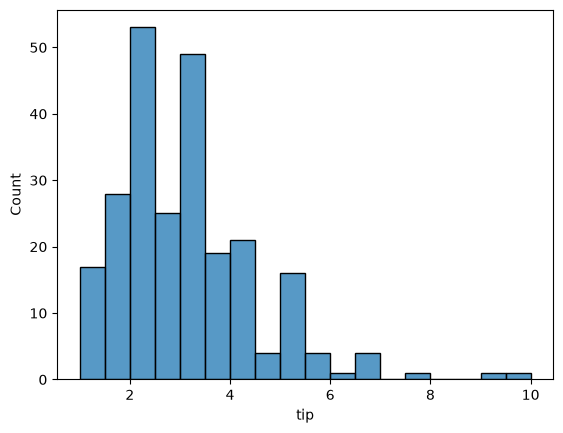

In [20]:
import matplotlib.pyplot as plt
sns.histplot(df['tip'])
plt.show()


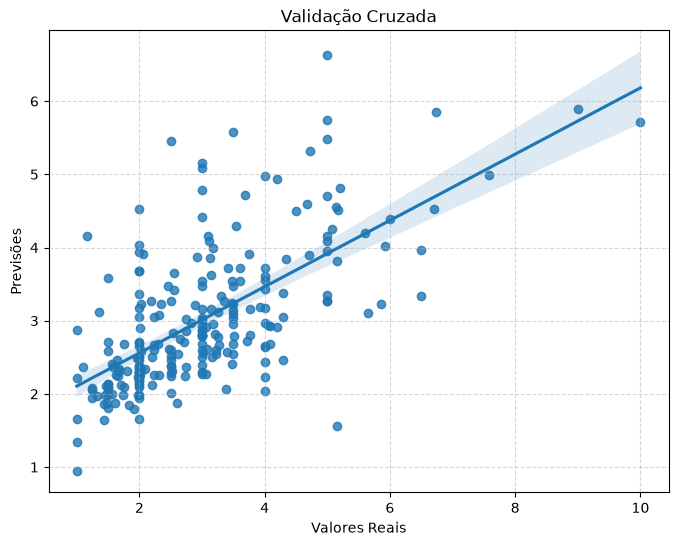

In [24]:
from sklearn.model_selection import cross_val_predict
# Gráfico de dispersão
cv = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred = cross_val_predict(model, X, y, cv=cv)
plt.figure(figsize=(8, 6))
sns.regplot(x = y, y = y_pred)
plt.xlabel("Valores Reais")
plt.ylabel("Previsões")
plt.title("Validação Cruzada")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()